# XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance
### SHAP Analysis

This is the final notebook of the project **"XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance"**

This notebook does SHAP analysis on the trained XGBoost model from Notebook 02. We plot the SHAP bar plot, SHAP Summary plot to look at which features explain the risk most. We then plot the dependence plot for FICO and LTV. 

Finally, a waterfall plot is used to explain the pricing on a high-risk and a low-risk loan. 

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import import_ipynb
import importlib
from IPython.display import display
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,make_scorer
from sklearn.impute import SimpleImputer
from mpl_toolkits.mplot3d import Axes3D
import joblib
import shap

In [2]:
#Load the xgboost notebook
xgboost_notebook = importlib.import_module('02_XGBoostModel')

In [3]:
#Reconstruct feature names
# Reconstruct feature names from preprocessor
#num_names = xgboost_notebook.num_feats
#cat_names = xgboost_notebook.preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(xgboost_notebook.cat_feats).tolist()
#all_feature_names = num_names + cat_names

#Build DataFrame for X_test
X_test = xgboost_notebook.X_test_transformed

In [4]:
#Look at the first few rows of the test dataset
X_test.head()

,Original Loan Balance ($),Original FICO Score,Original LTV (%),Original Interest Rate (%),Original DTI (%),Loan Purpose,Occupancy Type,Property State,Multiple Borrowers
0,314000.0,632.0,86.58,6.943,36.0,Refinance,Primary Residence,OH,Yes
1,259000.0,746.0,79.84,7.411,38.1,Purchase,Investment Property,UT,Yes
2,357000.0,754.0,85.93,6.998,35.2,Refinance,Primary Residence,IL,No
3,172000.0,740.0,80.27,6.675,33.0,Refinance,Primary Residence,WV,Yes
4,309000.0,693.0,83.41,7.173,35.2,Refinance,Investment Property,LA,Yes


In [5]:
#Building SHAP Explainer
explainer = shap.TreeExplainer(xgboost_notebook.xgboost_model_final)
shap_values = explainer.shap_values(xgboost_notebook.X_test_transformed)

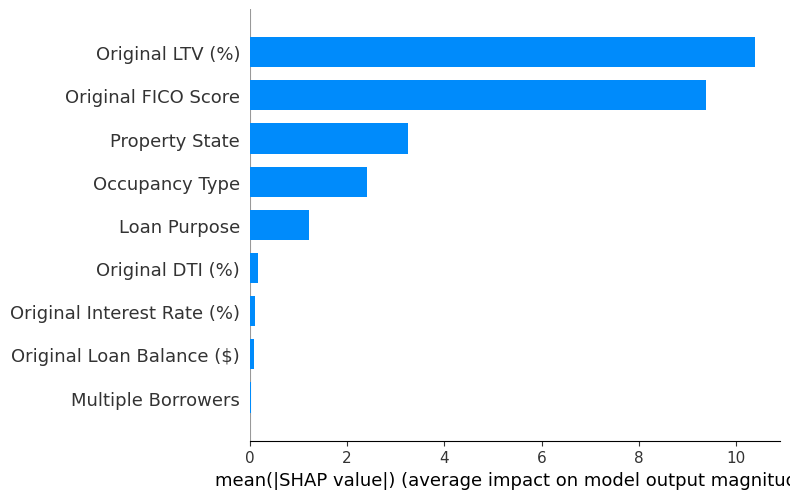

In [6]:
#SHAP Bar Plot
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=True)

LTV and FICO dominate feature importance by a large margin, confirming they are the primary drivers of MI premium rates. Property State and Occupancy Type contribute meaningfully as secondary factors, while Loan Purpose, DTI and the remaining features have minimal impact which is onsistent with how MI pricing works in practice.

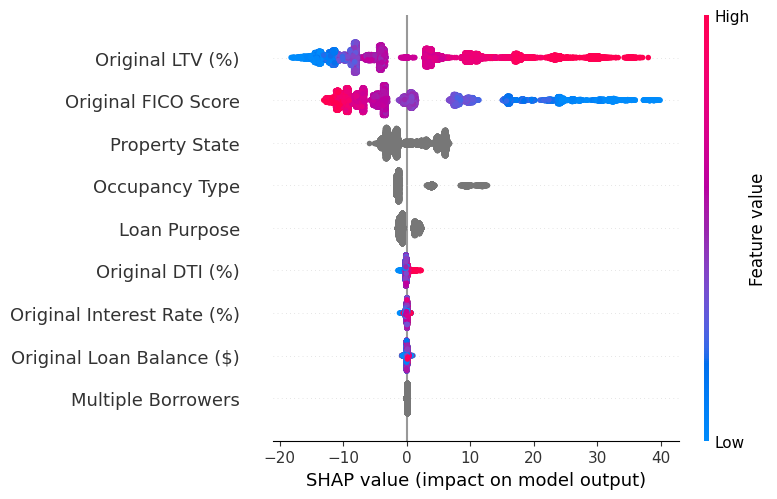

In [12]:
#SHAP summary plot
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig("images/key_drivers_of_prediction.png", dpi=300, bbox_inches='tight')
plt.show()

High LTV values (pink dots) push premiums up significantly while low LTV pulls them down, and the opposite pattern holds for FICO where high scores reduce premiums. Property State and Occupancy Type show visible spread confirming they carry real pricing signal, though far smaller than the two primary factors. DTI, interest rate, loan balance and multiple borrowers are essentially flat, showing the model correctly treats them as weak signals.

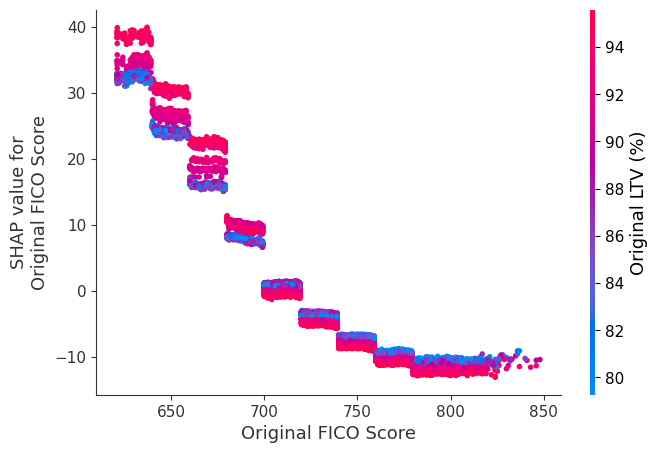

<Figure size 640x480 with 0 Axes>

In [8]:
#Dependence plot for FICO Score
shap.dependence_plot('Original FICO Score', shap_values, X_test,interaction_index='Original LTV (%)')
plt.tight_layout()
plt.show()

The staircase shape confirms that FICO affects premiums in discrete bands rather than continuously, which is exactly how MI pricing works in practice. The model has learned these thresholds purely from data without any explicit encoding. Within each FICO band, higher LTV loans (pink) tend to attract higher premiums, capturing the interaction between the two risk factors.

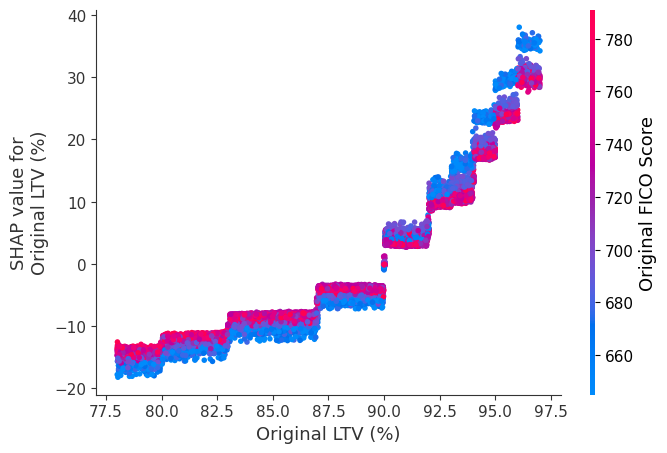

<Figure size 640x480 with 0 Axes>

In [9]:
#Dependence plot for LTV
shap.dependence_plot('Original LTV (%)', shap_values, X_test,interaction_index='Original FICO Score')
plt.tight_layout()
plt.show()

Similar to FICO, the LTV dependence plot shows clear pricing thresholds at the standard MI bands of 85, 90, 93 and 95. Premiums jump sharply at each threshold, particularly above 90 LTV. Within each LTV tier, lower FICO loans (blue) carry higher premiums, reflecting the interaction between the two key risk drivers.

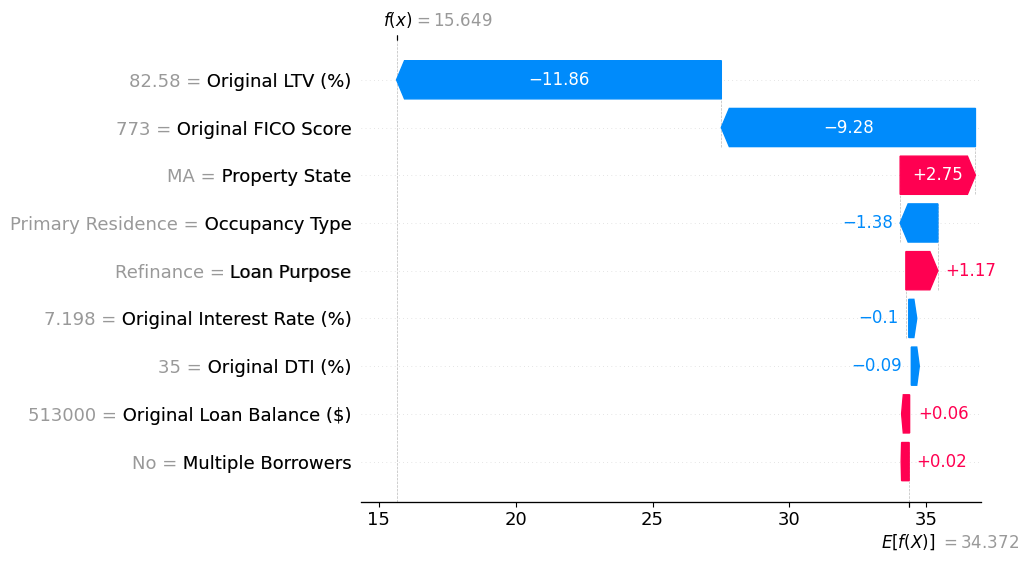

In [10]:
# Find a low risk loan — high FICO, low LTV
low_risk_idx = X_test[(X_test['Original FICO Score'] > 760) & 
                       (X_test['Original LTV (%)'] < 83)].index[0]

#Plot a waterfall plot
shap.waterfall_plot(shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[low_risk_idx],
    feature_names=X_test.columns
))

This loan has a FICO of 773 and LTV of 82.58, both pulling the predicted premium well below the portfolio average of 34.4 bps to a final prediction of 15.8 bps. The Massachusetts state indicator adds a small positive loading of 2.83 bps, and being a refinance loan adds a further 1.17 bps, but the dominant story is that strong credit quality and low equity risk together drive a significantly below average premium.

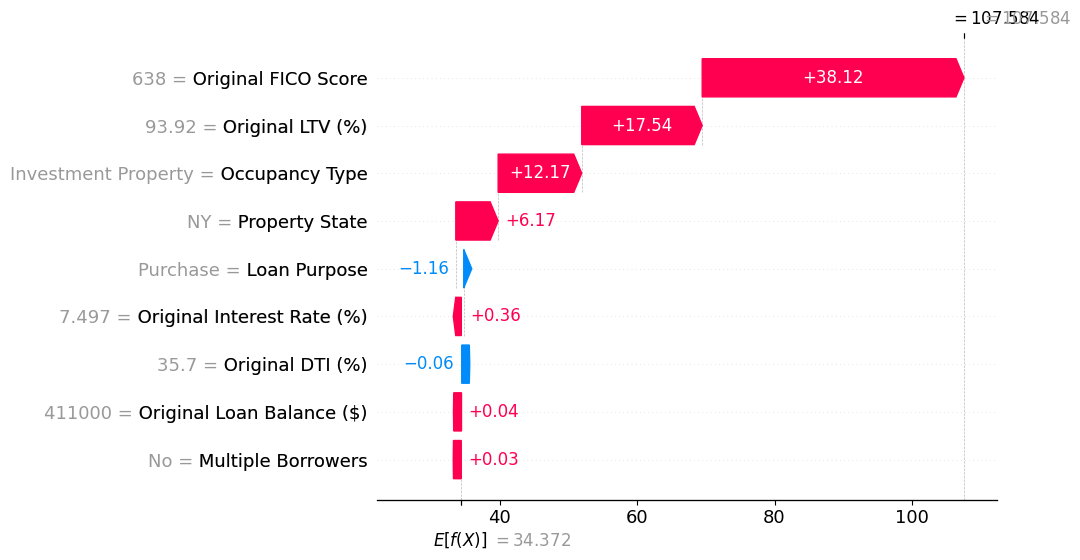

In [13]:
# Find a high risk loan — low FICO, high LTV
high_risk_idx = X_test[(X_test['Original FICO Score'] < 660) & 
                        (X_test['Original LTV (%)'] > 93)].index[0]
#Plot a waterfall plot
shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns
), show=False)
plt.savefig("images/sample_loan_waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

This loan with a FICO of 638 and LTV of 93.92 sits at the opposite end of the risk spectrum. FICO alone adds 37.9 bps above the average and LTV adds a further 17.5 bps. Being an investment property in New York adds 12.1 bps and 6.0 bps respectively, resulting in a final prediction of around 107 bps which is more than three times the portfolio average. Every feature for this loan points in the same direction, making it a clear example of how compounding risk factors drive extreme premium outcomes.

### End of Notebook